In [17]:
import sys
sys.path.append("..")

from src.signals import hat_function

# 1. Fourier-Reihe einer Hutfunktion (Reelle Fourier-Reihe)

### Approximation auf $[-\pi, \pi]$:
$$f(t) \approx \frac{a_0}{2} + \sum_{k=1}^N a_k \cos(kt) + b_k \sin(kt)$$

### Allgemeine Formel auf $[-L, L]$ (hier $L = \pi \implies$ Periode $2\pi$):
$$f(t) \approx \frac{a_0}{2} + \sum_{k=1}^{N} a_k \cos\left(\frac{k \pi t}{L}\right) + b_k \sin\left(\frac{k \pi t}{L}\right)$$

### Orthogonale Projektion & Normierung:
* **Projektionsformel:**
  $${\color{green}{\frac{1}{\left\|\cos\left(\frac{k \pi t}{L}\right)\right\|^2}}} \left\langle f(t), \; \cos\left(\frac{k \pi t}{L}\right) \right\rangle$$
    * **Normquadrat der Basisfunktion:**
  $$\left\|\cos\left(\frac{k \pi t}{L}\right)\right\|^2 = \int_{-L}^{L} \cos^2\left(\frac{k \pi t}{L}\right) dt = L \quad \xrightarrow{L=\pi} \quad \mathbf{\pi}$$
* **Koeffizienten-Integrale:**
  * **Gleichanteil (Mittelwert):**  
    $$a_0 = {{\color{green}\frac{1}{\pi}}} \int_{-\pi}^{\pi} f(t)\, dt$$
  * **Cosinus-Koeffizienten:**  
    $$a_k = {\color{green}{\frac{1}{\pi}}} \int_{-\pi}^{\pi} f(t) \cos(kt)\, dt$$
  * **Sinus-Koeffizienten:**  
    $$b_k = \frac{1}{\pi} \int_{-\pi}^{\pi} f(t) \sin(kt)\, dt = \mathbf{0} \quad \text{(da $f$ gerade)}$$


## 1.1 Definition des Testsignals (Hutfunktion)

Als Testsignal nehmen wir eine zentrierte Dreiecksfunktion (Hut) auf dem Intervall $[-\pi, \pi]$ mit einer Halbwertsbreite von $h = \frac{\pi}{2}$:

$$f(t) = \max\left(0, \; 1 - \frac{|t|}{\pi/2}\right) = \begin{cases} 
1 - \frac{2}{\pi}|t| & \text{für } |t| \le \frac{\pi}{2} \\[6pt] 
0 & \text{für } \frac{\pi}{2} < |t| \le \pi 
\end{cases}$$

**Die wichtigsten Eigenschaften auf einen Blick:**
- **Spitze bei $t = 0$:** Hier erreicht der Hut genau den Maximalwert $1$.
- **Linearer Abfall:** Zu beiden Seiten fällt die Gerade gleichmäßig ab, bis sie bei $t = \pm \frac{\pi}{2}$ die Nullinie erreicht. Außerhalb bleibt das Signal $0$.
- **Achsensymmetrisch:** $f(-t) = f(t)$, was uns die Sinus-Koeffizienten spart ($b_k = 0$).
- **Knicke:** Die Funktion hat drei scharfe Knickstellen (bei $-\frac{\pi}{2}$, $0$ und $+\frac{\pi}{2}$). Genau an diesen Kanten müssen die glatten Cosinus-Wellen arbeiten, um die Ecken nachzubilden.

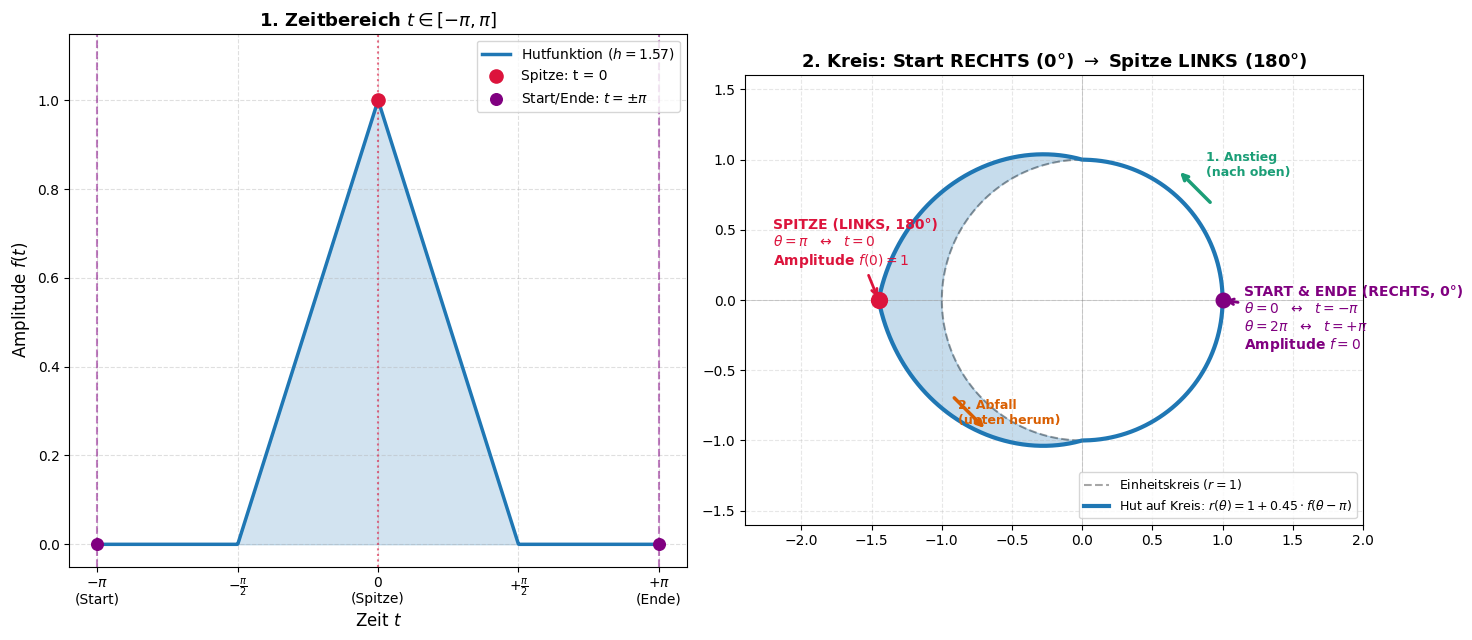

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------------
# 1. Parameter & Hutfunktion auf [-pi, pi]
# -------------------------------------------------------------------------
h = (
    np.pi / 2
)  # Halbwertsbreite pi/2 (Hut aktiv zwischen -pi/2 und +pi/2)
# h = np.pi       # Alternativ: Voller Hut über ganz [-pi, pi]


# t läuft von -pi bis +pi
t = np.linspace(-np.pi, np.pi, 1000)
f = hat_function(t, h)

# Drehwinkel: Startet RECHTS bei theta = 0 und läuft gegen den Uhrzeigersinn bis 2*pi
theta = t + np.pi

# -------------------------------------------------------------------------
# 2. Plot erstellen (2 Subplots nebeneinander)
# -------------------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))

# =========================================================================
# LINKER PLOT: 1D Zeitbereich [-pi, pi]
# =========================================================================
ax1.plot(t, f, color="#1f77b4", lw=2.5, label=f"Hutfunktion ($h = {h:.2f}$)")
ax1.fill_between(t, f, color="#1f77b4", alpha=0.2)

# Schlüsselpunkte markieren
ax1.scatter([0], [1], color="crimson", s=90, zorder=5, label="Spitze: t = 0")
ax1.scatter(
    [-np.pi, np.pi],
    [f[0], f[-1]],
    color="purple",
    s=70,
    zorder=5,
    label=r"Start/Ende: $t = \pm\pi$",
)

# Hilfslinien
ax1.axvline(0, color="crimson", linestyle=":", alpha=0.6)
ax1.axvline(-np.pi, color="purple", linestyle="--", alpha=0.5)
ax1.axvline(np.pi, color="purple", linestyle="--", alpha=0.5)

ax1.set_title(
    r"1. Zeitbereich $t \in [-\pi, \pi]$", fontsize=13, fontweight="bold"
)
ax1.set_xlabel(r"Zeit $t$", fontsize=12)
ax1.set_ylabel(r"Amplitude $f(t)$", fontsize=12)

# Ticks und Labels
ticks_x = [-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi]
labels_x = [
    r"$-\pi$" "\n(Start)",
    r"$-\frac{\pi}{2}$",
    r"$0$" "\n(Spitze)",
    r"$+\frac{\pi}{2}$",
    r"$+\pi$" "\n(Ende)",
]
ax1.set_xticks(ticks_x)
ax1.set_xticklabels(labels_x)

ax1.set_ylim([-0.05, 1.15])
ax1.grid(True, linestyle="--", alpha=0.4)
ax1.legend(loc="upper right")

# =========================================================================
# RECHTER PLOT: Kreis (Start RECHTS, Drehung nach oben, Spitze LINKS)
# =========================================================================
R0 = 1.0  # Radius des Einheitskreises
A = 0.45  # Auslenkung des Hutes
r_signal = R0 + A * f

# 1. Einheitskreis (Ruhelage f = 0)
theta_full = np.linspace(0, 2 * np.pi, 500)
x_circ = R0 * np.cos(theta_full)
y_circ = R0 * np.sin(theta_full)
ax2.plot(x_circ, y_circ, "k--", alpha=0.35, label="Einheitskreis ($r = 1$)")

# 2. Hutfunktion auf dem Kreis
x_sig = r_signal * np.cos(theta)
y_sig = r_signal * np.sin(theta)
ax2.plot(
    x_sig,
    y_sig,
    color="#1f77b4",
    lw=3,
    label=r"Hut auf Kreis: $r(\theta) = 1 + 0.45 \cdot f(\theta - \pi)$",
)

# 3. Fläche sauber füllen (als geschlossenes Polygon)
x_base = R0 * np.cos(theta)
y_base = R0 * np.sin(theta)
x_poly = np.concatenate([x_sig, x_base[::-1]])
y_poly = np.concatenate([y_sig, y_base[::-1]])
ax2.fill(x_poly, y_poly, color="#1f77b4", alpha=0.25)

# 4. SPITZE LINKS (theta = pi, t = 0)  --> OHNE \iff
x_spitze = -(R0 + A)
ax2.scatter([x_spitze], [0], color="crimson", s=130, zorder=6)
ax2.annotate(
    "SPITZE (LINKS, 180°)\n"
    r"$\theta = \pi$  $\leftrightarrow$  $t = 0$"
    "\n"
    r"Amplitude $f(0) = 1$",
    xy=(x_spitze, 0),
    xytext=(x_spitze - 0.75, 0.25),
    arrowprops=dict(arrowstyle="->", color="crimson", lw=2),
    fontweight="bold",
    color="crimson",
    fontsize=10,
)

# 5. START & ENDE RECHTS (theta = 0 bzw. 2*pi, t = -pi bzw. +pi) --> OHNE \iff
ax2.scatter([R0], [0], color="purple", s=110, zorder=6)
ax2.annotate(
    "START & ENDE (RECHTS, 0°)\n"
    r"$\theta = 0$  $\leftrightarrow$  $t = -\pi$"
    "\n"
    r"$\theta = 2\pi$  $\leftrightarrow$  $t = +\pi$"
    "\n"
    r"Amplitude $f = 0$",
    xy=(R0, 0),
    xytext=(R0 + 0.15, -0.35),
    arrowprops=dict(arrowstyle="->", color="purple", lw=2),
    fontweight="bold",
    color="purple",
    fontsize=10,
)

# 6. Drehrichtungspfeile (nach OBEN gegen den Uhrzeigersinn)
th_arr1 = np.pi / 4
ax2.annotate(
    "",
    xy=(1.15 * np.cos(th_arr1 + 0.15), 1.15 * np.sin(th_arr1 + 0.15)),
    xytext=(1.15 * np.cos(th_arr1 - 0.15), 1.15 * np.sin(th_arr1 - 0.15)),
    arrowprops=dict(arrowstyle="->", color="#1b9e77", lw=2.5),
)
ax2.text(
    1.25 * np.cos(th_arr1),
    1.25 * np.sin(th_arr1),
    "1. Anstieg\n(nach oben)",
    color="#1b9e77",
    fontweight="bold",
    fontsize=9,
)

th_arr2 = 5 * np.pi / 4
ax2.annotate(
    "",
    xy=(1.15 * np.cos(th_arr2 + 0.15), 1.15 * np.sin(th_arr2 + 0.15)),
    xytext=(1.15 * np.cos(th_arr2 - 0.15), 1.15 * np.sin(th_arr2 - 0.15)),
    arrowprops=dict(arrowstyle="->", color="#d95f02", lw=2.5),
)
ax2.text(
    1.25 * np.cos(th_arr2),
    1.25 * np.sin(th_arr2),
    "2. Abfall\n(unten herum)",
    color="#d95f02",
    fontweight="bold",
    fontsize=9,
)

# Achsenkreuz
ax2.axhline(0, color="gray", lw=0.6, alpha=0.4)
ax2.axvline(0, color="gray", lw=0.6, alpha=0.4)

ax2.set_title(
    "2. Kreis: Start RECHTS (0°) $\\rightarrow$ Spitze LINKS (180°)",
    fontsize=13,
    fontweight="bold",
)
ax2.set_aspect("equal")
ax2.set_xlim([-2.4, 2.0])
ax2.set_ylim([-1.6, 1.6])
ax2.grid(True, linestyle="--", alpha=0.3)
ax2.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()


<>:16: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:16: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/_b/2nrtxbx96f5fczm846vvgh3h0000gn/T/ipykernel_18139/122021756.py:16: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  plt.title('Testsignal: Symmetrische Hutfunktion auf $[-\pi, \pi]$', fontsize=12)


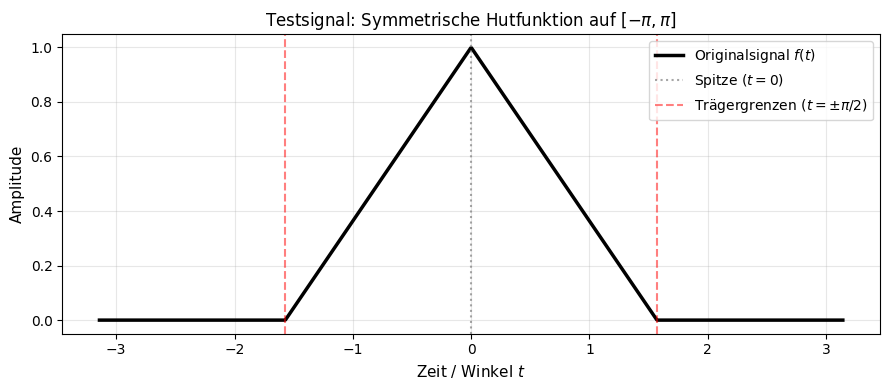

In [19]:
import numpy as np
import matplotlib.pyplot as plt




# Signalabtastung für Plot
t_ref = np.linspace(-np.pi, np.pi, 1000)
f_ref = hat_function(t_ref)

plt.figure(figsize=(9, 4))
plt.plot(t_ref, f_ref, 'k-', lw=2.5, label=r'Originalsignal $f(t)$')
plt.axvline(0, color='gray', linestyle=':', alpha=0.7, label=r'Spitze ($t=0$)')
plt.axvline(-np.pi/2, color='r', linestyle='--', alpha=0.5, label=r'Trägergrenzen ($t=\pm \pi/2$)')
plt.axvline(np.pi/2, color='r', linestyle='--', alpha=0.5)
plt.title('Testsignal: Symmetrische Hutfunktion auf $[-\pi, \pi]$', fontsize=12)
plt.xlabel('Zeit / Winkel $t$', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## 1.2 Wie schnell nähert sich die Reihe an? (Konvergenz)

- **Glattheit bestimmt das Tempo:**  
  In der Fourier-Analysis gilt die Faustregel: Je glatter eine Funktion, desto schneller fallen ihre Koeffizienten ab. Da unsere Hutfunktion (linearer-Spline) stetig ist, aber harte Knicke hat (die Ableitung springt(vor 0 +, nach 0 -)), fallen die Koeffizienten langsamer mit $f \in C^{p-1}$ und $f^{(p)}$ stückweise stetig $\implies a_k = \mathcal{O}(k^{-(p+1)})$, hier: $p=1$ ($f \in C^0$, Knickstellen an der Spitze und den Rändern):
  $$a_k = \mathcal{O}\left(\frac{1}{k^2}\right)$$
  Höhere Frequenzen werden also quadratisch kleiner und tragen immer feinere Details bei.

- **Zusammenspiel an der Spitze ($t = 0$):**  
  Für $t = 0$ ist $\cos(k \cdot 0) = 1$ für jedes beliebige $k \in [1,N]$. Das bedeutet: Alle Harmonischen haben hier ihr Maximum und ziehen am selben Strang:
  $$f(0) \approx \frac{a_0}{2} + \sum_{k=1}^N a_k = 1$$
  Die negative Krümmung der Cosinus-Wellen ($-k^2$) sorgt dafür, dass sich die scharfe Spitze immer spitzer ausbildet.

In [20]:
# Abtastgitter
N_samples = 2000
t_grid = np.linspace(-np.pi, np.pi, N_samples, endpoint=False)
dt = t_grid[1] - t_grid[0]
f_vals = hat_function(t_grid)

# Maximale Fourier-Ordnung
N_order = 30
a_k = np.zeros(N_order + 1)
b_k = np.zeros(N_order + 1)

# Gleichanteil a_0 (Projektion mit 1/pi)
a_0 = (1.0 / np.pi) * np.sum(f_vals) * dt
a_k[0] = a_0

# Fourier-Integrale über diskrete Quadratur
for k in range(1, N_order + 1):
    a_k[k] = (1.0 / np.pi) * np.sum(f_vals * np.cos(k * t_grid)) * dt
    b_k[k] = (1.0 / np.pi) * np.sum(f_vals * np.sin(k * t_grid)) * dt

print(f"Gleichanteil a_0 = {a_0:.6f} (analytisch: 0.500000)")
print(f"Cosinus-Koeffizienten a_1 bis a_5: {np.round(a_k[1:6], 6)}")
print(f"Maximaler Betrag max(|b_k|): {np.max(np.abs(b_k[1:])):.2e}")
print("-> Verifikation: b_k ist auf Maschinengenauigkeit 0.")

Gleichanteil a_0 = 0.500000 (analytisch: 0.500000)
Cosinus-Koeffizienten a_1 bis a_5: [ 0.405285  0.202643  0.045032 -0.        0.016212]
Maximaler Betrag max(|b_k|): 3.55e-17
-> Verifikation: b_k ist auf Maschinengenauigkeit 0.


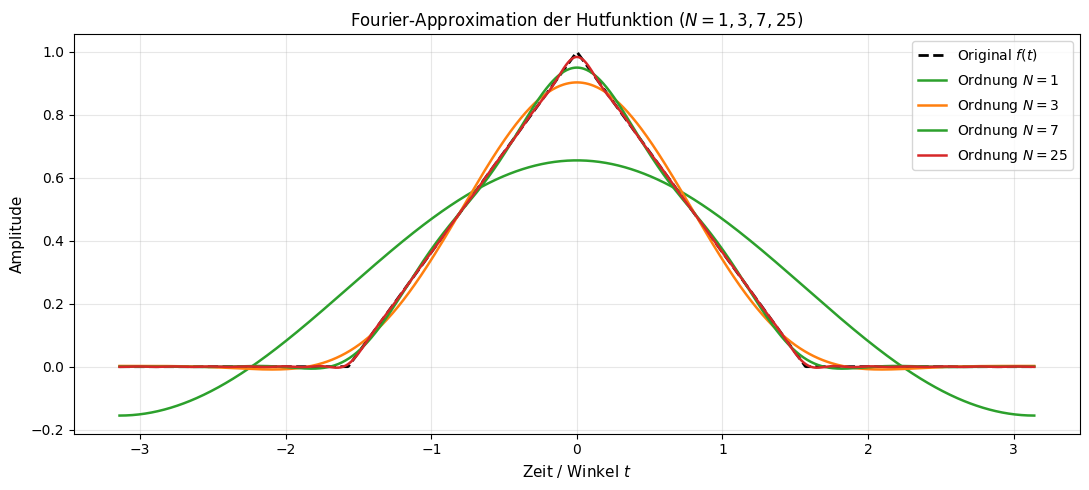

In [21]:
def fourier_reconstruct(t, a_k, b_k, n):
    res = a_k[0] / 2.0
    for k in range(1, n + 1):
        res += a_k[k] * np.cos(k * t) + b_k[k] * np.sin(k * t)
    return res

orders = [1, 3, 7, 25]
plt.figure(figsize=(11, 5))
plt.plot(t_ref, f_ref, 'k--', lw=2, label=r'Original $f(t)$')

colors = ['tab:green', 'tab:orange', 'tab:green', 'tab:red']
for n, c in zip(orders, colors):
    plt.plot(t_ref, fourier_reconstruct(t_ref, a_k, b_k, n), color=c, lw=1.8, label=f'Ordnung $N = {n}$')

plt.title('Fourier-Approximation der Hutfunktion ($N = 1, 3, 7, 25$)', fontsize=12)
plt.xlabel('Zeit / Winkel $t$', fontsize=11)
plt.ylabel('Amplitude', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

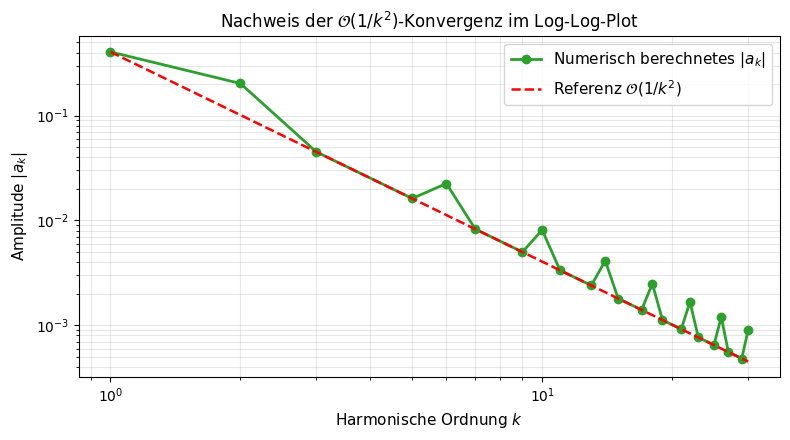

In [22]:
k_indices = np.arange(1, N_order + 1)
a_magnitudes = np.abs(a_k[1:])

mask = a_magnitudes > 1e-12
k_valid = k_indices[mask]
a_valid = a_magnitudes[mask]

plt.figure(figsize=(8, 4.5))
plt.loglog(k_valid, a_valid, 'o-', color='tab:green', lw=2, ms=6, label=r'Numerisch berechnetes $|a_k|$')
plt.loglog(k_valid, a_valid[0] * (k_valid[0] / k_valid)**2, 'r--', lw=1.8, label=r'Referenz $\mathcal{O}(1/k^2)$')
plt.title(r'Nachweis der $\mathcal{O}(1/k^2)$-Konvergenz im Log-Log-Plot', fontsize=12)
plt.xlabel('Harmonische Ordnung $k$', fontsize=11)
plt.ylabel(r'Amplitude $|a_k|$', fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 1.3 Numerische Stabilität: Rundungsfehler & Konditionierung

- **Keine Auslöschung:**  
  Gefährliche Auslöschung (Catastrophic Cancellation) passiert in Gleitkommazahlen nur, wenn zwei fast gleich große Zahlen voneinander subtrahiert werden. An der Spitze summieren wir aber lauter positive Werte ($a_k \ge 0$) auf. Auslöschung ist also ausgeschlossen.

- **Gutartige Konditionierung:**  
  Eine einfache Summe besitzt die absolute Konditionszahl $\kappa_{\text{abs}} = 1$. Eingabefehler werden also nicht künstlich verstärkt.

- **Rundungsfehler in float64:**  
  Bei doppelter Genauigkeit (ca. 16 Dezimalstellen) liegt der akkumulierte Rundungsfehler selbst bei $N = 1000$ Summanden in der Größenordnung von $\approx 10^{-13}$. Der Rechenfehler am Rechner ist also praktisch vernachlässigbar.